🚀 启动 10 核心并行扫描 | 目标：1000 个采样点
✅ 完成！总耗时: 483.92 分钟


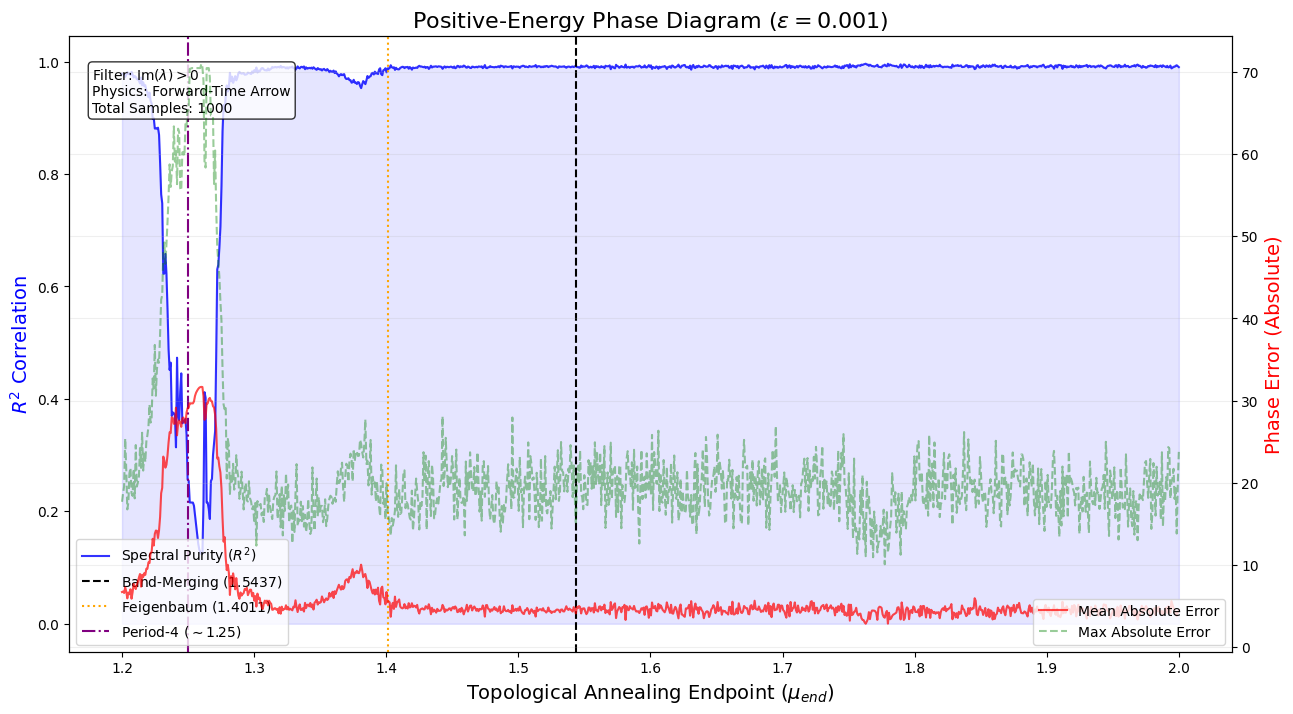

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
import os
from numba import njit
import multiprocessing as mp

# ================== 1. 真实的黎曼零点准备 ==================
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

# ================== 2. 高斯核概率溅射引擎 (保持不变) ==================
@njit(fastmath=True, nogil=True)
def run_universe_gaussian_splatting(steps, n_bins, u_c, k_opt, c_offset, eps):
    # (此处省略内部逻辑，保持您原来的 Numba 代码)
    # ... 原有逻辑 ...
    dx = 2.0 / n_bins
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    V = np.zeros(n_bins, dtype=np.float64)
    init_bin = int((0.5 + 1.0) / dx)
    if init_bin >= n_bins: init_bin = n_bins - 1
    elif init_bin < 0: init_bin = 0
    V[init_bin] = 1.0 
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    radius = int(5.0 * eps / dx) + 1 
    for n in range(1, steps + 1):
        mu_raw = u_c + k_opt / (np.log(n + c_offset)**2)
        mu = max(0.1, min(2.0, mu_raw))
        V_next = np.zeros(n_bins, dtype=np.float64)
        for i in range(n_bins):
            if V[i] < 1e-12: continue
            x = -1.0 + dx * 0.5 + i * dx
            x_next = 1.0 - mu * x * x
            j_center = int((x_next + 1.0) / dx)
            j_start = max(0, j_center - radius)
            j_end = min(n_bins - 1, j_center + radius)
            w_sum = 0.0
            for j in range(j_start, j_end + 1):
                cj = -1.0 + dx * 0.5 + j * dx
                dist_sq = (cj - x_next) * (cj - x_next)
                w_sum += np.exp(-dist_sq * inv_2eps2)
            if w_sum > 1e-18:
                inv_w_sum = 1.0 / w_sum
                for j in range(j_start, j_end + 1):
                    cj = -1.0 + dx * 0.5 + j * dx
                    dist_sq = (cj - x_next) * (cj - x_next)
                    prob = np.exp(-dist_sq * inv_2eps2) * inv_w_sum
                    flow = V[i] * prob
                    V_next[j] += flow
                    transitions[i, j] += flow
            else:
                jc = max(0, min(n_bins-1, j_center))
                V_next[jc] += V[i]
                transitions[i, jc] += V[i]
        V = V_next
    return transitions

# ================== 3. 单点计算 Worker ==================
def compute_point(mu_end):
    TOTAL_STEPS = 10**5    
    C_OFFSET = 10.0   
    DELTA_MU_ABS = 0.02    
    EPSILON = 0.001 
    
    t_start_val = 1.0 / (np.log(1 + C_OFFSET)**2)
    t_end_val   = 1.0 / (np.log(TOTAL_STEPS + C_OFFSET)**2)
    k_opt = DELTA_MU_ABS / (t_start_val - t_end_val)
    u_c = mu_end - k_opt * t_end_val
    
    try:
        trans = run_universe_gaussian_splatting(TOTAL_STEPS, 5000, u_c, k_opt, C_OFFSET, EPSILON)
        P_sparse = sp.csr_matrix(trans)
        row_sums = np.array(P_sparse.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1.0 
        P_sparse.data /= row_sums[P_sparse.indices]
        
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS*2 + 20, which='LM', tol=1e-4)
        positive_eigs = eigenvalues[eigenvalues.imag > 1e-4]
        phases = np.sort(np.angle(positive_eigs))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            errors = np.abs(pred - true_zeros_trunc)
            return (mu_end, r_val**2, np.mean(errors), np.max(errors), np.std(errors))
    except:
        pass
    return (mu_end, 0.0, 20.0, 20.0, 0.0)

# ================== 4. 并行调度与主程序 ==================
if __name__ == "__main__":
    test_points = np.linspace(1.20, 2.00, 1000) # 1000个点，开启高精模式
    num_cpus = 10 # 适配 AutoDL 节点
    
    print(f"🚀 启动 10 核心并行扫描 | 目标：1000 个采样点")
    t_start = time.time()
    
    with mp.Pool(processes=num_cpus) as pool:
        results = pool.map(compute_point, test_points)
    
    # 结果解包
    mu_list, r2_list, mean_err, max_err, std_err = zip(*results)
    
    print(f"✅ 完成！总耗时: {(time.time()-t_start)/60:.2f} 分钟")

    # ================== 5. 极致作图 (修复 SyntaxWarning) ==================
    fig, ax1 = plt.subplots(figsize=(15, 8))
    ax2 = ax1.twinx()

    # R2 填充区 (加了 r 前缀修复转义)
    ax1.plot(mu_list, r2_list, 'b-', alpha=0.8, label=r'Spectral Purity ($R^2$)')
    ax1.fill_between(mu_list, r2_list, color='blue', alpha=0.1)
    
    # 误差线
    ax2.plot(mu_list, mean_err, 'r-', alpha=0.7, label='Mean Absolute Error')
    ax2.plot(mu_list, max_err, 'g--', alpha=0.4, label='Max Absolute Error')

    # 标注地标 (使用 r"" 修复 \sim 等报错)
    ax1.axvline(1.543689, color='k', linestyle='--', label=r'Band-Merging ($1.5437$)')
    ax1.axvline(1.401155, color='orange', linestyle=':', label=r'Feigenbaum ($1.4011$)')
    ax1.axvline(1.25, color='purple', linestyle='-.', label=r'Period-4 ($\sim 1.25$)')

    ax1.set_xlabel(r'Topological Annealing Endpoint ($\mu_{end}$)', fontsize=14)
    ax1.set_ylabel(r'$R^2$ Correlation', color='b', fontsize=14)
    ax2.set_ylabel(r'Phase Error (Absolute)', color='r', fontsize=14)
    
    # 修复 Title 和 Text 里的 \epsilon 等字符
    ax1.set_title(r'Positive-Energy Phase Diagram ($\epsilon = 0.001$)', fontsize=16)
    
    info_box = (r"Filter: $\text{Im}(\lambda) > 0$" + "\n" +
                r"Physics: Forward-Time Arrow" + "\n" +
                r"Total Samples: 1000")
    ax1.text(0.02, 0.95, info_box, transform=ax1.transAxes, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax1.legend(loc='lower left')
    ax2.legend(loc='lower right')
    plt.grid(alpha=0.2)
    plt.show()